In [38]:
import os
import glob
import datetime

import jax
import numpyro
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import hssm
import arviz as az
import seaborn as sns

import sqlite3

jax.config.update('jax_platform_name', 'cpu')
hssm.set_floatX("float32")
numpyro.set_host_device_count(14)

Setting PyTensor floatX type to float32.
Setting "jax_enable_x64" to False. If this is not intended, please set `jax` to False.


In [39]:
df_exp = pd.read_csv('data/hssm_exp4_data_ab.csv')

In [40]:
df_exp

,response,rt,participant_id,ab_nominal
0,0,1.4546,708,0.05
1,0,2.0167,708,0.05
2,1,0.9597,708,0.05
3,1,0.9102,708,0.05
4,0,1.0218,708,0.05
...,...,...,...,...
26508,1,1.3294,1113,10.00
26509,1,1.5069,1113,10.00
26510,1,1.3452,1113,10.00
26511,0,2.3210,1113,10.00


In [83]:
df_exp['X'] = df_exp['ab_nominal'].map({0.05: 0, 10: 1})
df_exp['response'] = df_exp['response'].map({0: -1, 1: 1})

In [42]:
df_sim = pd.read_csv('data/hssm_simulated_data.csv')

# plot

In [43]:
def plot_rt_quantiles_participant(
    participant_id,
    real_df,
    sim_df,
    rt_col="rt",
    pid_col="participant_id",
    quantiles=np.linspace(0.1, 0.9, 9)
):
    """
    Plot RT quantile curves for one participant:
    real data vs simulated data.
    """

    # --- standardize dtypes ---
    participant_id = str(participant_id)
    real_df = real_df.copy()
    sim_df = sim_df.copy()

    real_df[pid_col] = real_df[pid_col].astype(str)
    sim_df[pid_col] = sim_df[pid_col].astype(str)

    # --- subset participant ---
    real_p = real_df[real_df[pid_col] == participant_id]
    sim_p  = sim_df[sim_df[pid_col] == participant_id]

    if real_p.empty or sim_p.empty:
        print(f"Participant {participant_id} not found in one of the datasets")
        pass
        #raise ValueError(f"Participant {participant_id} not found in both datasets")

    # --- compute quantiles ---
    real_q = real_p[rt_col].quantile(quantiles).values
    sim_q  = sim_p[rt_col].quantile(quantiles).values

    # --- plot ---
    plt.figure(figsize=(5, 4))
    plt.plot(quantiles, real_q, 'o-', label="Experimental Data")
    plt.plot(quantiles, sim_q,  's--', label="Simulation")

    plt.xlabel("Quantile")
    plt.ylabel("Reaction time (sec)")
    plt.title(f"Participant {participant_id} – RT quantiles")
    plt.legend()
    plt.tight_layout()
    plt.show()

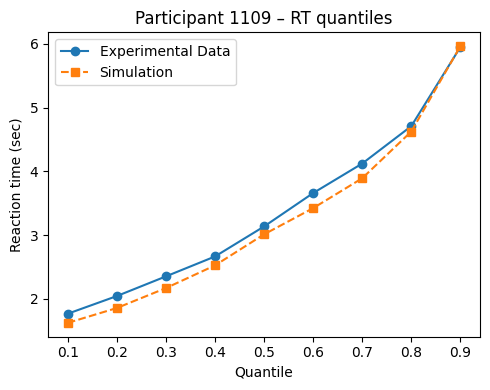

In [44]:
plot_rt_quantiles_participant(1109, df_exp, df_sim)

# 10 random plots

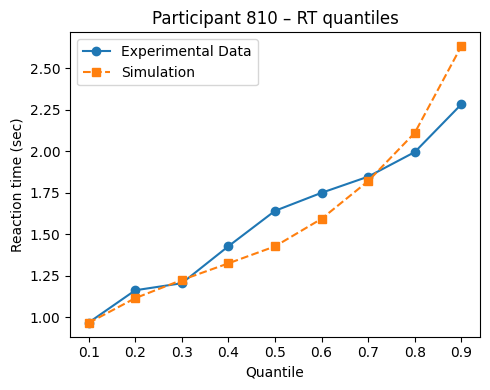

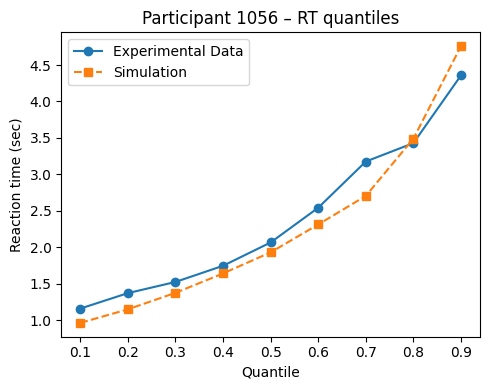

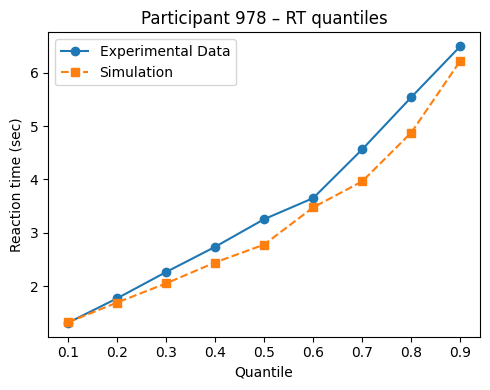

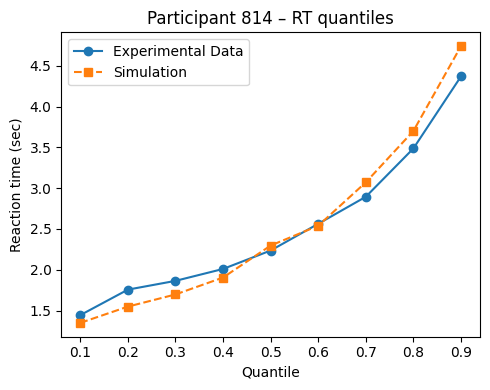

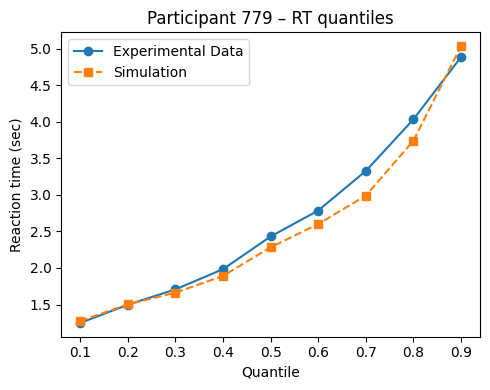

Participant 896 not found in one of the datasets


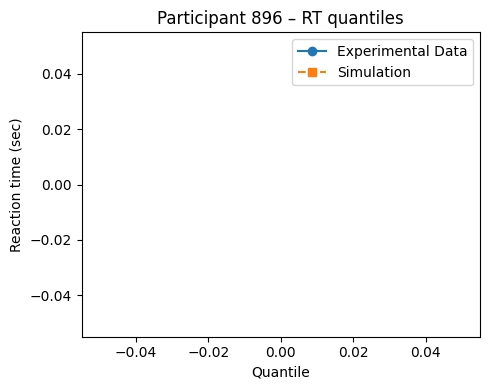

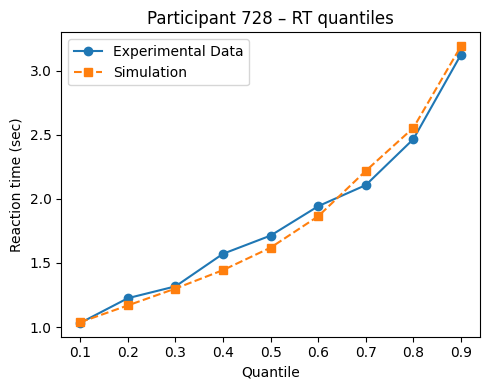

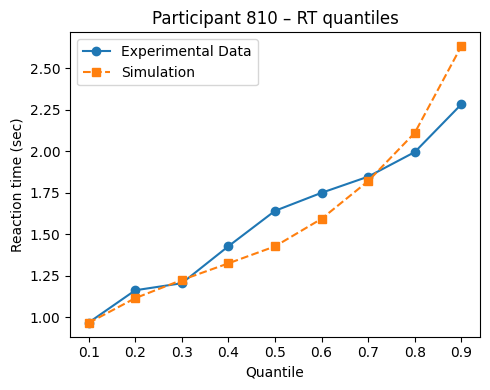

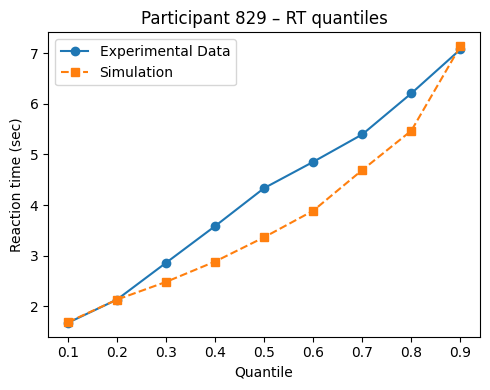

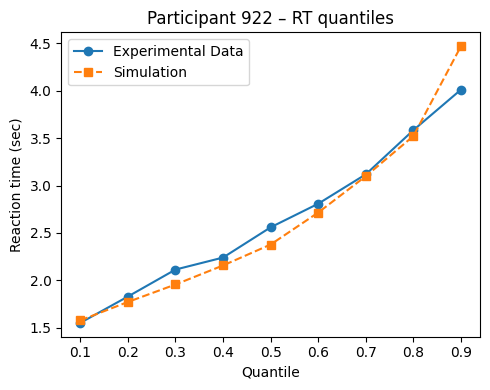

In [45]:
np.random.seed(42)
x = np.random.randint(df_exp['participant_id'].min(), df_exp['participant_id'].max()+1, size=10)
for x in x:
    plot_rt_quantiles_participant(x, df_exp, df_sim)

# Group plot

In [46]:
def plot_rt_quantiles_group(
    real_df,
    sim_df,
    rt_col="rt",
    pid_col="participant_id",
    quantiles=np.linspace(0.1, 0.9, 9),
    show_sem=True,
    title="Group-average RT quantiles"
):
    """
    Plot group-average RT quantile curves:
    real data vs simulated data.
    """

    # --- standardize dtypes ---
    real_df = real_df.copy()
    sim_df  = sim_df.copy()

    real_df[pid_col] = real_df[pid_col].astype(str)
    sim_df[pid_col]  = sim_df[pid_col].astype(str)

    # --- helper: participant-level quantiles ---
    def participant_quantiles(df):
        return df[rt_col].quantile(quantiles).values

    # --- real data ---
    real_Q = (
        real_df
        .groupby(pid_col)
        .apply(participant_quantiles)
        .to_list()
    )
    real_Q = np.vstack(real_Q)

    real_mean = real_Q.mean(axis=0)
    real_sem  = real_Q.std(axis=0) / np.sqrt(real_Q.shape[0])

    # --- simulated data ---
    sim_Q = (
        sim_df
        .groupby(pid_col)
        .apply(participant_quantiles)
        .to_list()
    )
    sim_Q = np.vstack(sim_Q)

    sim_mean = sim_Q.mean(axis=0)

    # --- plot ---
    plt.figure(figsize=(5, 4))

    plt.plot(quantiles, real_mean, 'o-', label="Data")
    if show_sem:
        plt.fill_between(
            quantiles,
            real_mean - real_sem,
            real_mean + real_sem,
            alpha=0.3
        )

    plt.plot(quantiles, sim_mean, 's--', label="DDM simulation")

    plt.errorbar(
    quantiles,
    real_mean,
    yerr=real_sem,
    fmt='none',
    capsize=3,
    alpha=0.7
)


    plt.xlabel("Quantile")
    plt.ylabel("Reaction time")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

In [47]:
df_exp_1 = df_exp[df_exp['response'] == 1]
df_exp_0 = df_exp[df_exp['response'] == 0]
df_sim_1 = df_sim[df_sim['response'] == 1]
df_sim_0 = df_sim[df_sim['response'] == -1]

/var/folders/65/zt7m7_71489b2xgz9mqdpfl40000gn/T/ipykernel_21090/187465573.py:28: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  real_df
/var/folders/65/zt7m7_71489b2xgz9mqdpfl40000gn/T/ipykernel_21090/187465573.py:40: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sim_df


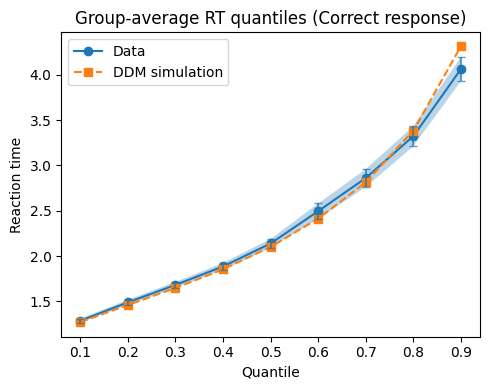

In [48]:
plot_rt_quantiles_group(
    real_df=df_exp_1,
    sim_df=df_sim_1,
    title="Group-average RT quantiles (Correct response)"
)

/var/folders/65/zt7m7_71489b2xgz9mqdpfl40000gn/T/ipykernel_21090/187465573.py:28: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  real_df
/var/folders/65/zt7m7_71489b2xgz9mqdpfl40000gn/T/ipykernel_21090/187465573.py:40: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sim_df


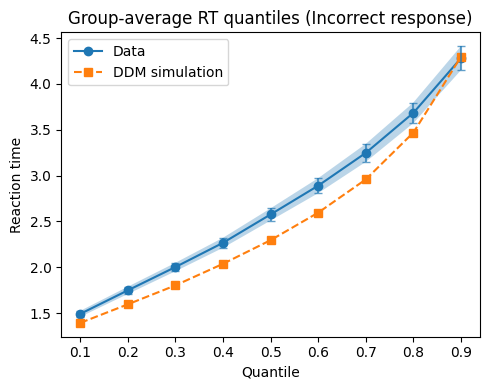

In [49]:
plot_rt_quantiles_group(
    real_df=df_exp_0,
    sim_df=df_sim_0,
    title = "Group-average RT quantiles (Incorrect response)"
)

# new plots

In [50]:
def plot_accuracy_quantiles_group(
    real_df,
    sim_df,
    rt_col="rt",
    acc_col="correct",
    pid_col="participant_id",
    quantiles=np.linspace(0.1, 0.9, 9),
    show_sem=True,
    title="Group-average accuracy by RT quantile"
):
    """
    Plot group-average accuracy as a function of RT quantiles
    (conditional accuracy function).
    """

    real_df = real_df.copy()
    sim_df  = sim_df.copy()

    real_df[pid_col] = real_df[pid_col].astype(str)
    sim_df[pid_col]  = sim_df[pid_col].astype(str)

    # --- helper: participant-level accuracy per RT quantile ---
    def participant_acc_by_rt_quantile(df):
        qs = df[rt_col].quantile(quantiles).values
        acc = []
        for i, q in enumerate(qs):
            if i == 0:
                mask = df[rt_col] <= q
            else:
                mask = (df[rt_col] > qs[i-1]) & (df[rt_col] <= q)
            acc.append(df.loc[mask, acc_col].mean())
        return np.array(acc)

    # --- real data ---
    real_Q = (
        real_df
        .groupby(pid_col)
        .apply(participant_acc_by_rt_quantile)
        .to_list()
    )
    real_Q = np.vstack(real_Q)

    real_mean = real_Q.mean(axis=0)
    real_sem  = real_Q.std(axis=0) / np.sqrt(real_Q.shape[0])

    # --- simulated data ---
    sim_Q = (
        sim_df
        .groupby(pid_col)
        .apply(participant_acc_by_rt_quantile)
        .to_list()
    )
    sim_Q = np.vstack(sim_Q)

    sim_mean = sim_Q.mean(axis=0)

    # --- plot ---
    plt.figure(figsize=(5, 4))

    plt.plot(quantiles, real_mean, 'o-', label="Data")
    if show_sem:
        plt.fill_between(
            quantiles,
            real_mean - real_sem,
            real_mean + real_sem,
            alpha=0.3
        )

    plt.plot(quantiles, sim_mean, 's--', label="DDM simulation")

    plt.errorbar(
        quantiles,
        real_mean,
        yerr=real_sem,
        fmt='none',
        capsize=3,
        alpha=0.7
    )

    plt.xlabel("RT quantile")
    plt.ylabel("Accuracy")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()


In [51]:
def plot_accuracy_group(
    real_df,
    sim_df,
    acc_col="correct",
    pid_col="participant_id",
    show_sem=True,
    title="Group-average accuracy"
):
    """
    Plot group-average mean accuracy:
    real data vs simulated data.
    """

    real_df = real_df.copy()
    sim_df  = sim_df.copy()

    real_df[pid_col] = real_df[pid_col].astype(str)
    sim_df[pid_col]  = sim_df[pid_col].astype(str)

    # --- helper: participant-level mean accuracy ---
    def participant_accuracy(df):
        return df[acc_col].mean()

    # --- real data ---
    real_acc = (
        real_df
        .groupby(pid_col)
        .apply(participant_accuracy)
        .values
    )

    real_mean = real_acc.mean()
    real_sem  = real_acc.std() / np.sqrt(len(real_acc))

    # --- simulated data ---
    sim_acc = (
        sim_df
        .groupby(pid_col)
        .apply(participant_accuracy)
        .values
    )

    sim_mean = sim_acc.mean()

    # --- plot ---
    plt.figure(figsize=(4, 4))

    plt.bar([0], [real_mean], yerr=[real_sem] if show_sem else None, capsize=4, label="Data")
    plt.bar([1], [sim_mean], label="DDM simulation")

    plt.xticks([0, 1], ["Data", "DDM"])
    plt.ylabel("Accuracy")
    plt.title(title)
    plt.tight_layout()
    plt.show()


In [52]:
df_sim

,rt,response,participant_id
0,1.213996,1.0,935
1,2.338023,1.0,935
2,1.099998,1.0,935
3,1.291995,1.0,935
4,2.658036,1.0,935
...,...,...,...
102895,1.174994,1.0,1111
102896,1.284993,1.0,1111
102897,1.429991,1.0,1111
102898,1.526994,1.0,1111


In [53]:
plot_accuracy_quantiles_group(
    real_df=df_exp,
    sim_df=df_sim,
    title="Group-average accuracy"
)

KeyError: 'correct'

# group plots per incentive

# group plots for different models

In [ ]:
from hssm_plots import plot_rt_quantiles_group

In [ ]:
with sqlite3.connect('hssm_sims.sqlite') as conn:
    df_ddm_mod_th = pd.read_sql("SELECT * FROM th_ddm;", conn)
    th_df = pd.DataFrame(df_ddm_mod_th)

    df_ddm_mod_v = pd.read_sql("SELECT * FROM v_ddm;", conn)
    v_df = pd.DataFrame(df_ddm_mod_v)

    df_ddm_pure = pd.read_sql("SELECT * FROM pure_ddm;", conn)
    pure_df = pd.DataFrame(df_ddm_pure)

In [ ]:
df_sim_th_1 = th_df[th_df['response'] == 1]
df_sim_th_0 = th_df[th_df['response'] == -1]
df_sim_v_1 = v_df[v_df['response'] == 1]
df_sim_v_0 = v_df[v_df['response'] == -1]

/var/folders/65/zt7m7_71489b2xgz9mqdpfl40000gn/T/ipykernel_21090/187465573.py:28: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  real_df
/var/folders/65/zt7m7_71489b2xgz9mqdpfl40000gn/T/ipykernel_21090/187465573.py:40: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sim_df


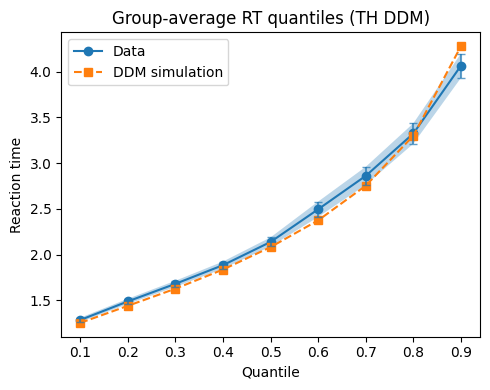

In [ ]:
plot_rt_quantiles_group(
    real_df=df_exp_1,
    sim_df=df_sim_th_1,
    title="Group-average RT quantiles (TH DDM)"
)

/var/folders/65/zt7m7_71489b2xgz9mqdpfl40000gn/T/ipykernel_21090/187465573.py:28: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  real_df
/var/folders/65/zt7m7_71489b2xgz9mqdpfl40000gn/T/ipykernel_21090/187465573.py:40: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sim_df


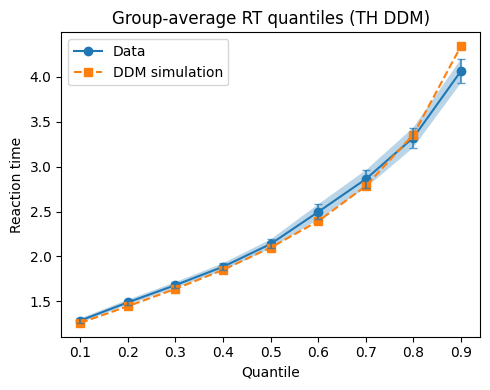

In [ ]:
plot_rt_quantiles_group(
    real_df=df_exp_1,
    sim_df=df_sim_v_1,
    title="Group-average RT quantiles (TH DDM)"
)

/var/folders/65/zt7m7_71489b2xgz9mqdpfl40000gn/T/ipykernel_21090/187465573.py:28: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  real_df
/var/folders/65/zt7m7_71489b2xgz9mqdpfl40000gn/T/ipykernel_21090/187465573.py:40: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sim_df


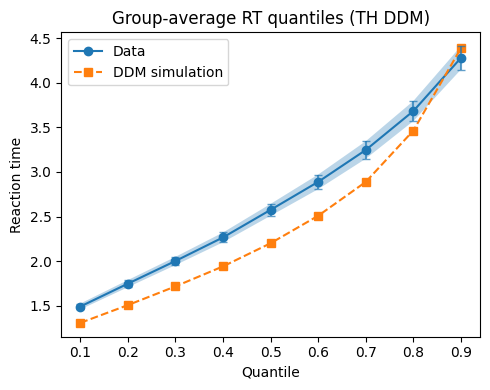

In [ ]:
plot_rt_quantiles_group(
    real_df=df_exp_0,
    sim_df=df_sim_th_0,
    title="Group-average RT quantiles (TH DDM)"
)

/var/folders/65/zt7m7_71489b2xgz9mqdpfl40000gn/T/ipykernel_21090/187465573.py:28: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  real_df
/var/folders/65/zt7m7_71489b2xgz9mqdpfl40000gn/T/ipykernel_21090/187465573.py:40: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sim_df


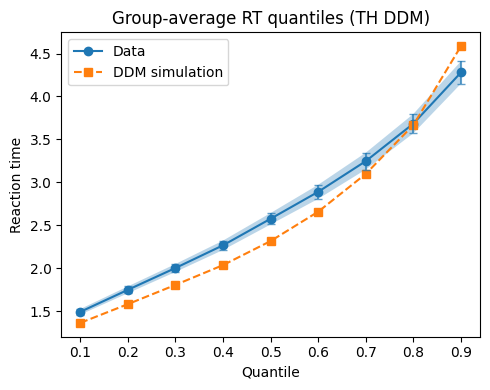

In [ ]:
plot_rt_quantiles_group(
    real_df=df_exp_0,
    sim_df=df_sim_v_0,
    title="Group-average RT quantiles (TH DDM)"
)

# comparing incentives

In [56]:
# corrects
df_sim_th_1_inc = th_df[(th_df['response'] == 1) & (th_df['X'] == 1)]
df_sim_th_1_no = th_df[(th_df['response'] == 1) & (th_df['X'] == 0)]
df_sim_v_1_inc = v_df[(v_df['response'] == 1) & (v_df['X'] == 1)]
df_sim_v_1_no = v_df[(v_df['response'] == 1) & (v_df['X'] == 0)]

df_exp_1_inc = df_exp[(df_exp['response'] == 1) & (df_exp['X'] == 1)]
df_exp_1_no = df_exp[(df_exp['response'] == 1) & (df_exp['X'] == 0)]

#incorrects

df_sim_th_0_inc = th_df[(th_df['response'] == 0) & (th_df['X'] == 1)]
df_sim_th_0_no = th_df[(th_df['response'] == 0) & (th_df['X'] == 0)]
df_sim_v_0_inc = v_df[(v_df['response'] == 0) & (v_df['X'] == 1)]
df_sim_v_0_no = v_df[(v_df['response'] == 0) & (v_df['X'] == 0)]

df_exp_0_inc = df_exp[(df_exp['response'] == 0) & (df_exp['X'] == 1)]
df_exp_0_no = df_exp[(df_exp['response'] == 0) & (df_exp['X'] == 0)]

/var/folders/65/zt7m7_71489b2xgz9mqdpfl40000gn/T/ipykernel_21090/187465573.py:28: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  real_df
/var/folders/65/zt7m7_71489b2xgz9mqdpfl40000gn/T/ipykernel_21090/187465573.py:40: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sim_df


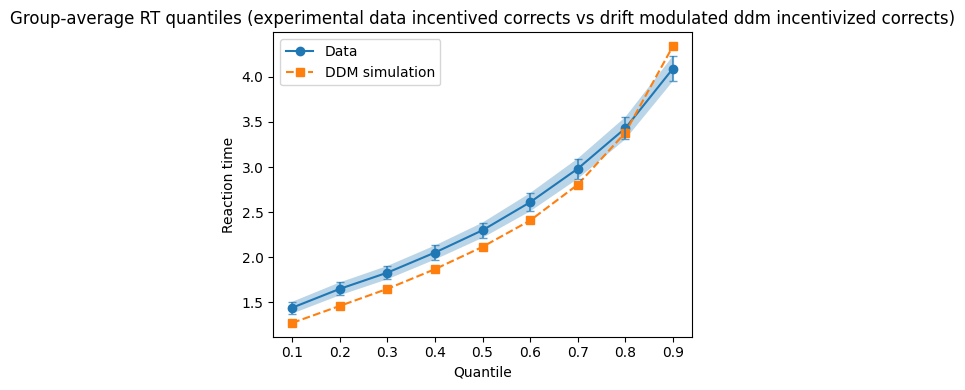

In [58]:
plot_rt_quantiles_group(
    real_df=df_exp_1_inc,
    sim_df=df_sim_v_1_inc,
    title="Group-average RT quantiles (experimental data incentived corrects vs drift modulated ddm incentivized corrects)"
)

/var/folders/65/zt7m7_71489b2xgz9mqdpfl40000gn/T/ipykernel_21090/187465573.py:28: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  real_df
/var/folders/65/zt7m7_71489b2xgz9mqdpfl40000gn/T/ipykernel_21090/187465573.py:40: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sim_df


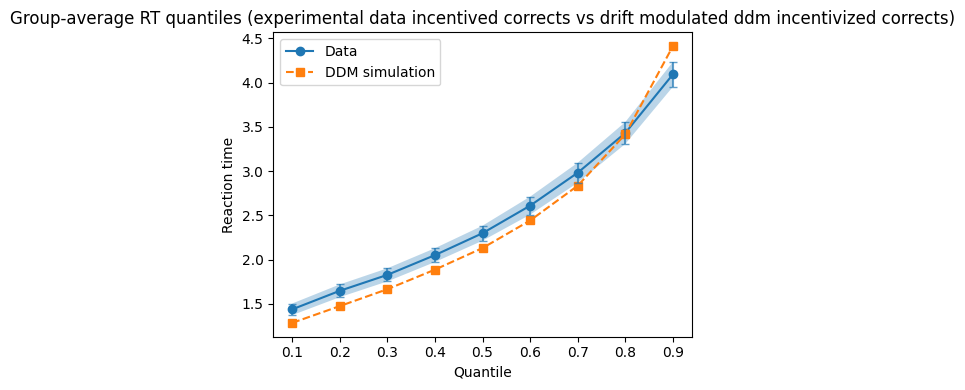

In [59]:
plot_rt_quantiles_group(
    real_df=df_exp_1_inc,
    sim_df=df_sim_th_1_inc,
    title="Group-average RT quantiles (experimental data incentived corrects vs drift modulated ddm incentivized corrects)"
)

# gemini

In [81]:
th_df[th_df["response"] == -1]

,rt,response,participant_id,X
0,1.576992,-1.0,935,0
2,1.326993,-1.0,935,0
3,2.398030,-1.0,935,0
17,0.931999,-1.0,935,0
18,0.749000,-1.0,935,0
...,...,...,...,...
102887,0.829999,-1.0,1111,1
102888,2.527033,-1.0,1111,0
102890,0.933997,-1.0,1111,1
102892,1.003997,-1.0,1111,0


In [76]:
import matplotlib.pyplot as plt
import numpy as np

def plot_all_models_rt(df_exp, df_th, df_v, df_pure, response=1, incentive=1, rt_col="rt", pid_col="participant_id"):
    quantiles = np.linspace(0.1, 0.9, 9)
    
    # YOUR ORIGINAL HELPER FUNCTION (kept exactly as is)
    def get_q(df): 
        subset = df[(df['response'] == response) & (df['X'] == incentive)]
        return np.vstack(subset.groupby(pid_col).apply(lambda x: x[rt_col].quantile(quantiles).values).to_list())
    
    # Apply your logic to all 4 sources
    real_Q = get_q(df_exp)
    th_Q   = get_q(df_th)
    v_Q    = get_q(df_v)
    pure_Q = get_q(df_pure)
    
    # Calculate means and SEM for the experimental data
    r_mean, r_sem = real_Q.mean(axis=0), real_Q.std(axis=0) / np.sqrt(real_Q.shape[0])
    
    plt.figure(figsize=(10, 6))

    # Plot Real Data with the shaded SEM (Your style)
    plt.plot(quantiles, r_mean, 'o-', color='black', label="Experimental Data", linewidth=2)
    plt.fill_between(quantiles, r_mean - r_sem, r_mean + r_sem, color='black', alpha=0.2)
    
    # Plot the 3 Simulations as lines
    plt.plot(quantiles, th_Q.mean(axis=0), 's--', label="Threshold Mod (a)")
    plt.plot(quantiles, v_Q.mean(axis=0), '^--', label="Drift Mod (v)")
    plt.plot(quantiles, pure_Q.mean(axis=0), 'v--', color='gray', label="Pure DDM")

    # Titles based on input
    acc_text = "Correct" if response == 1 else "Incorrect"
    inc_text = "Incentivized" if incentive == 1 else "No-Incentive"
    plt.title(f"Group RT Quantiles: {acc_text} trials ({inc_text})")
    
    plt.xlabel("Quantiles")
    plt.ylabel("RT (s)")
    plt.legend()
    plt.show()

/var/folders/65/zt7m7_71489b2xgz9mqdpfl40000gn/T/ipykernel_21090/2755908945.py:10: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return np.vstack(subset.groupby(pid_col).apply(lambda x: x[rt_col].quantile(quantiles).values).to_list())
/var/folders/65/zt7m7_71489b2xgz9mqdpfl40000gn/T/ipykernel_21090/2755908945.py:10: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return np.vstack(subset.groupby(pid_col).apply

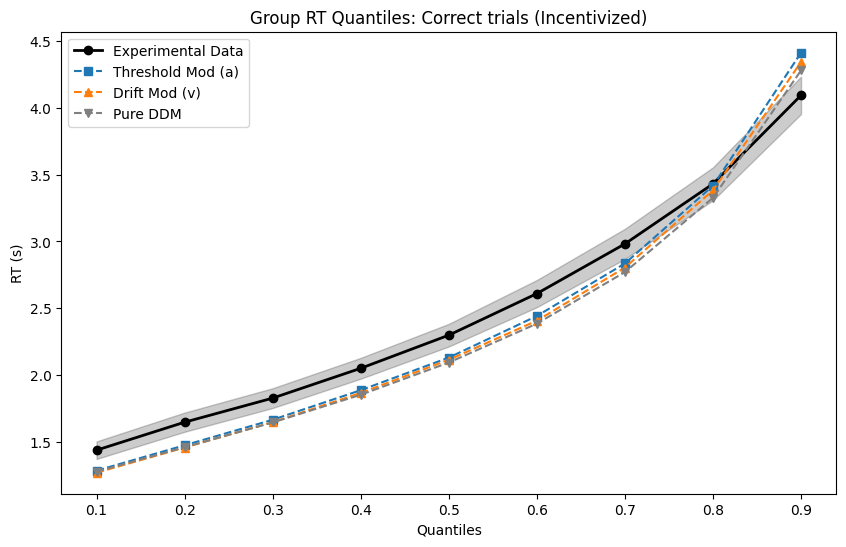

In [77]:
# Now you can just run this one line:
plot_all_models_rt(df_exp, th_df, v_df, pure_df, response=1, incentive=1)

/var/folders/65/zt7m7_71489b2xgz9mqdpfl40000gn/T/ipykernel_21090/2755908945.py:10: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return np.vstack(subset.groupby(pid_col).apply(lambda x: x[rt_col].quantile(quantiles).values).to_list())
/var/folders/65/zt7m7_71489b2xgz9mqdpfl40000gn/T/ipykernel_21090/2755908945.py:10: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return np.vstack(subset.groupby(pid_col).apply

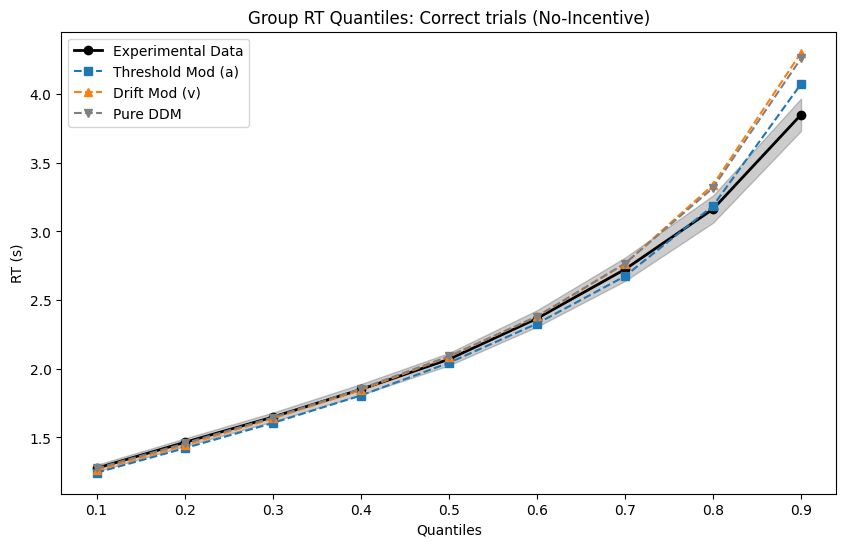

In [78]:
# Now you can just run this one line:
plot_all_models_rt(df_exp, th_df, v_df, pure_df, response=1, incentive=0)

/var/folders/65/zt7m7_71489b2xgz9mqdpfl40000gn/T/ipykernel_21090/2755908945.py:10: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return np.vstack(subset.groupby(pid_col).apply(lambda x: x[rt_col].quantile(quantiles).values).to_list())
/var/folders/65/zt7m7_71489b2xgz9mqdpfl40000gn/T/ipykernel_21090/2755908945.py:10: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return np.vstack(subset.groupby(pid_col).apply

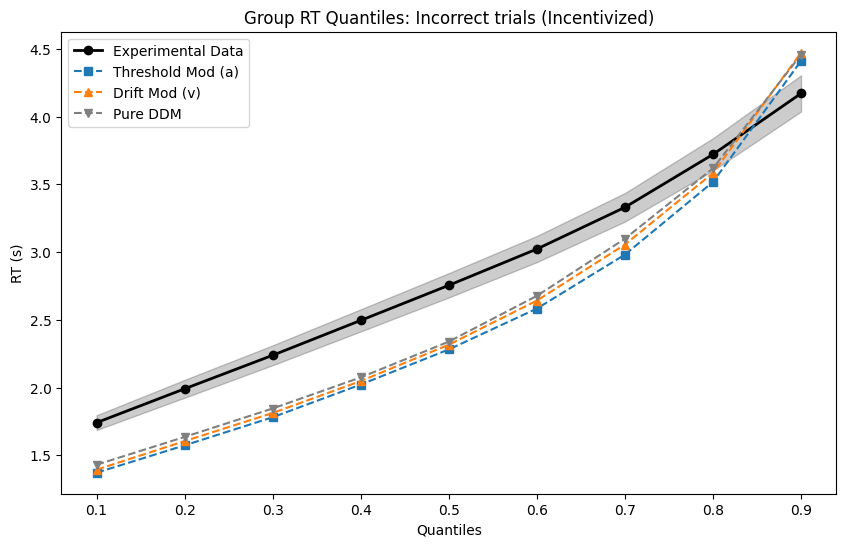

In [85]:
# Now you can just run this one line:
plot_all_models_rt(df_exp, th_df, v_df, pure_df, response=-1, incentive=1)

/var/folders/65/zt7m7_71489b2xgz9mqdpfl40000gn/T/ipykernel_21090/2755908945.py:10: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return np.vstack(subset.groupby(pid_col).apply(lambda x: x[rt_col].quantile(quantiles).values).to_list())
/var/folders/65/zt7m7_71489b2xgz9mqdpfl40000gn/T/ipykernel_21090/2755908945.py:10: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return np.vstack(subset.groupby(pid_col).apply

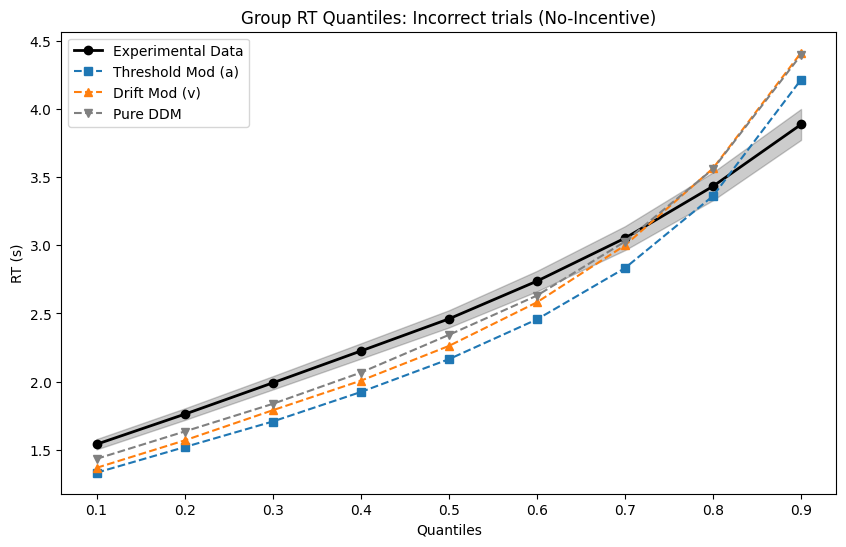

In [86]:
# Now you can just run this one line:
plot_all_models_rt(df_exp, th_df, v_df, pure_df, response=-1, incentive=0)

# all

/var/folders/65/zt7m7_71489b2xgz9mqdpfl40000gn/T/ipykernel_21090/2243253934.py:11: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return np.vstack(subset.groupby(pid_col).apply(lambda x: x[rt_col].quantile(quantiles).values).to_list())
/var/folders/65/zt7m7_71489b2xgz9mqdpfl40000gn/T/ipykernel_21090/2243253934.py:11: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return np.vstack(subset.groupby(pid_col).apply

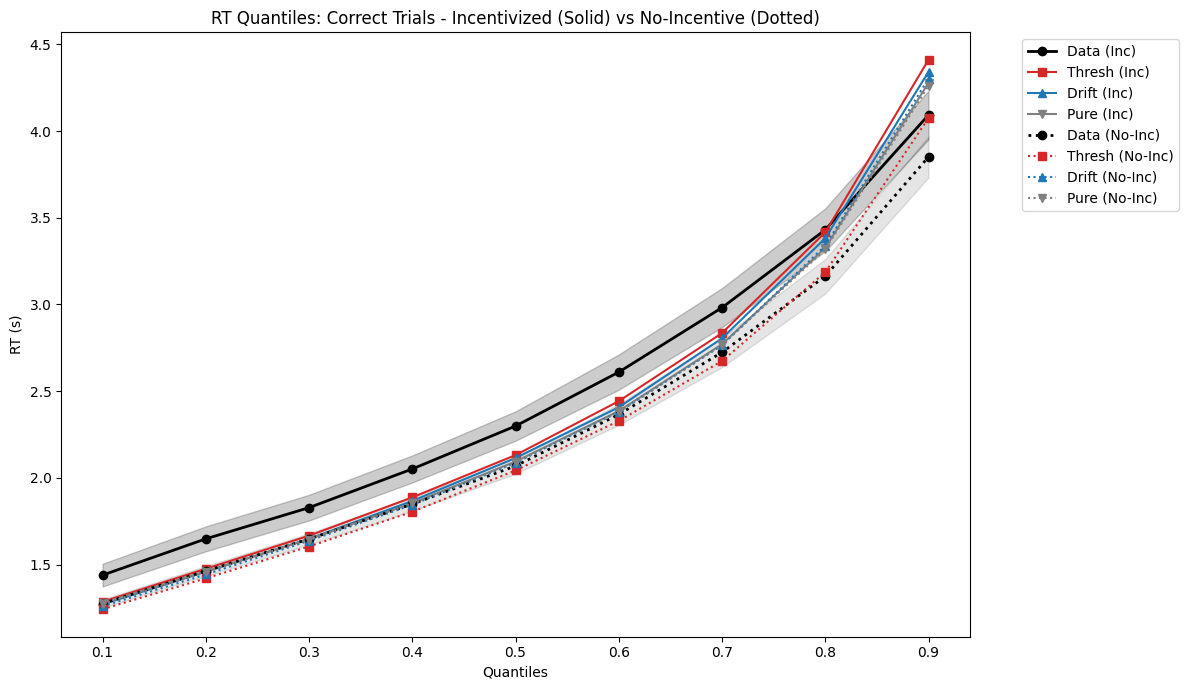

In [103]:
import matplotlib.pyplot as plt
import numpy as np

def plot_incentive_comparison(df_exp, df_th, df_v, df_pure, response=1, rt_col="rt", pid_col="participant_id"):
    quantiles = np.linspace(0.1, 0.9, 9)
    
    # Updated helper to accept 'inc' argument
    def get_q(df, inc): 
        subset = df[(df['response'] == response) & (df['X'] == inc)]
        if subset.empty: return None
        return np.vstack(subset.groupby(pid_col).apply(lambda x: x[rt_col].quantile(quantiles).values).to_list())
    
    plt.figure(figsize=(12, 7))

    # Define colors for models to keep it readable
    colors = {'exp': 'black', 'th': '#d62728', 'v': '#1f77b4', 'pure': 'gray'}

    # Loop through both incentive conditions
    for inc, style, alpha_val in [(1, '-', 0.2), (0, ':', 0.1)]:
        label_suffix = " (Inc)" if inc == 1 else " (No-Inc)"
        
        # Pull Quantiles
        r_Q = get_q(df_exp, inc)
        th_Q = get_q(df_th, inc)
        v_Q = get_q(df_v, inc)
        p_Q = get_q(df_pure, inc)

        # 1. Plot Experimental Data with SEM
        if r_Q is not None:
            r_mean = r_Q.mean(axis=0)
            r_sem = r_Q.std(axis=0) / np.sqrt(r_Q.shape[0])
            plt.plot(quantiles, r_mean, 'o' + style, color=colors['exp'], label=f"Data{label_suffix}", linewidth=2)
            plt.fill_between(quantiles, r_mean - r_sem, r_mean + r_sem, color=colors['exp'], alpha=alpha_val)

        # 2. Plot Models
        if th_Q is not None:
            #pass
            plt.plot(quantiles, th_Q.mean(axis=0), 's' + style, color=colors['th'], label=f"Thresh{label_suffix}")
        if v_Q is not None:
            #pass
            plt.plot(quantiles, v_Q.mean(axis=0), '^' + style, color=colors['v'], label=f"Drift{label_suffix}")
        if p_Q is not None:
            #pass
            plt.plot(quantiles, p_Q.mean(axis=0), 'v' + style, color=colors['pure'], label=f"Pure{label_suffix}")

    acc_text = "Correct" if response == 1 else "Incorrect"
    plt.title(f"RT Quantiles: {acc_text} Trials - Incentivized (Solid) vs No-Incentive (Dotted)")
    plt.xlabel("Quantiles")
    plt.ylabel("RT (s)")
    
    # Legend outside because it's getting crowded
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

# Run for all corrects
plot_incentive_comparison(df_exp, th_df, v_df, pure_df, response=1)

# accuracy plot

/var/folders/65/zt7m7_71489b2xgz9mqdpfl40000gn/T/ipykernel_21090/1328230344.py:17: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  part_stats = df.groupby(['participant_id', 'X']).apply(
/var/folders/65/zt7m7_71489b2xgz9mqdpfl40000gn/T/ipykernel_21090/1328230344.py:17: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  part_stats = df.groupby(['participant_id', 'X']).apply(
/var/folders/65/zt7m7_71489b2xgz9mqdpfl4

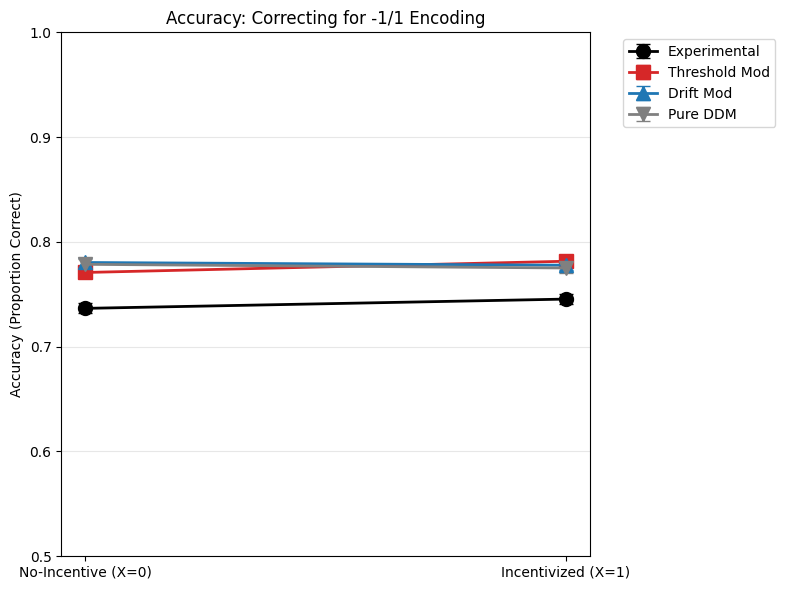

In [98]:
import matplotlib.pyplot as plt
import numpy as np

def plot_accuracy_corrected_coding(df_exp, df_th, df_v, df_pure):
    def get_stats(df):
        # 1. Calculate accuracy: (Number of 1s) / (Total Number of trials)
        def calc_acc(sub_df):
            if len(sub_df) == 0: return 0
            return (sub_df['response'] == 1).sum() / len(sub_df)

        # Global accuracy for the line points
        acc_0 = calc_acc(df[df['X'] == 0])
        acc_1 = calc_acc(df[df['X'] == 1])
        
        # 2. Per-participant accuracy for the Error Bars (SEM)
        # We apply the same 'is equal to 1' logic per participant
        part_stats = df.groupby(['participant_id', 'X']).apply(
            lambda x: (x['response'] == 1).sum() / len(x)
        ).unstack()
        
        means = [acc_1, acc_0]
        sems = [
            part_stats[1].std() / np.sqrt(part_stats[1].count()),
            part_stats[0].std() / np.sqrt(part_stats[0].count())
        ]
        return means, sems

    sources = {
        'Exp': (df_exp, 'black', 'o', 'Experimental'),
        'Thresh': (df_th, '#d62728', 's', 'Threshold Mod'),
        'Drift': (df_v, '#1f77b4', '^', 'Drift Mod'),
        'Pure': (df_pure, 'gray', 'v', 'Pure DDM')
    }

    plt.figure(figsize=(8, 6))
    x_axis = [1, 0] 
    
    for key, (df, col, mark, lab) in sources.items():
        m, s = get_stats(df)
        plt.errorbar(x_axis, m, yerr=s, fmt=mark + '-', color=col, 
                     label=lab, capsize=5, markersize=10, linewidth=2)

    plt.xticks([1, 0], ['Incentivized (X=1)', 'No-Incentive (X=0)'])
    plt.ylabel('Accuracy (Proportion Correct)')
    plt.title('Accuracy: Correcting for -1/1 Encoding')
    plt.ylim(0.5, 1.0) # Accuracy can't be below 0.5 (chance) easily here
    plt.grid(axis='y', alpha=0.3)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

plot_accuracy_corrected_coding(df_exp, th_df, v_df, pure_df)

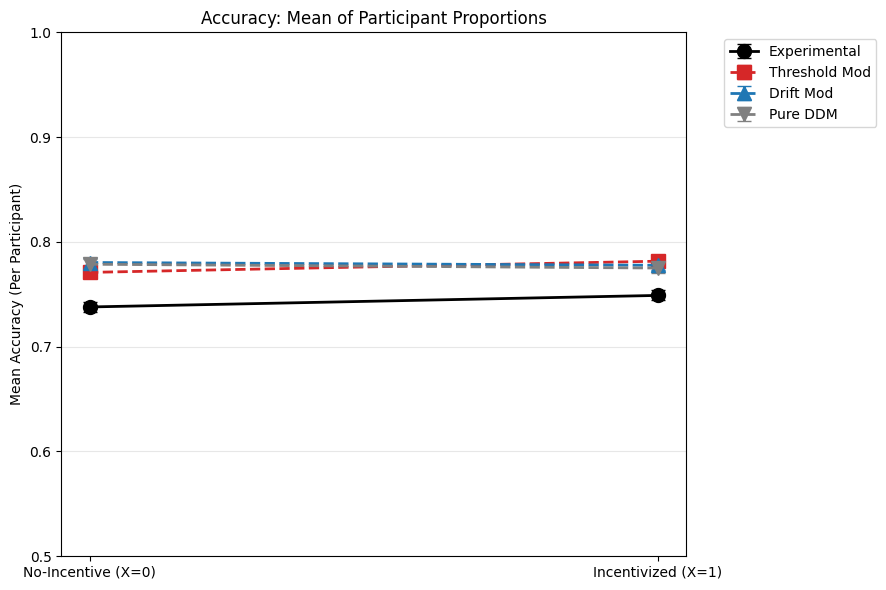

In [99]:
import matplotlib.pyplot as plt
import numpy as np

def plot_accuracy_per_participant(df_exp, df_th, df_v, df_pure, pid_col="participant_id"):
    def get_acc_stats(df):
        # 1. Transform response to a boolean (True for 1, False for -1) 
        # then group by participant and incentive (X) to get accuracy per person
        # This ensures a person with 75% correct is 0.75, not 0.5
        stats = df.assign(is_correct = lambda x: x['response'] == 1) \
                  .groupby([pid_col, 'X'])['is_correct'].mean().unstack()
        
        # 2. Calculate the group-level mean of those individual accuracies
        # stats[1] is Incentivized, stats[0] is No-Incentive
        means = [stats[1].mean(), stats[0].mean()]
        
        # 3. Calculate SEM (Standard Error of the Mean) across participants
        sems = [
            stats[1].std() / np.sqrt(stats[1].count()), 
            stats[0].std() / np.sqrt(stats[0].count())
        ]
        return means, sems

    # Get stats for all sources
    res_exp = get_acc_stats(df_exp)
    res_th  = get_acc_stats(df_th)
    res_v   = get_acc_stats(df_v)
    res_pure = get_acc_stats(df_pure)

    # Plotting
    plt.figure(figsize=(9, 6))
    conditions = [1, 0]
    labels = ['Incentivized (X=1)', 'No-Incentive (X=0)']
    
    # Define styles to stay consistent with your RT plots
    configs = [
        (res_exp, 'black', 'o-', 'Experimental'),
        (res_th, '#d62728', 's--', 'Threshold Mod'),
        (res_v, '#1f77b4', '^--', 'Drift Mod'),
        (res_pure, 'gray', 'v--', 'Pure DDM')
    ]

    for (m, s), color, fmt, lab in configs:
        plt.errorbar(conditions, m, yerr=s, fmt=fmt, color=color, 
                     label=lab, capsize=5, markersize=10, linewidth=2)

    plt.xticks(conditions, labels)
    plt.ylabel('Mean Accuracy (Per Participant)')
    plt.title('Accuracy: Mean of Participant Proportions')
    plt.ylim(0.5, 1.0) # Accuracy shouldn't drop below chance (0.5)
    plt.grid(axis='y', alpha=0.3)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

plot_accuracy_per_participant(df_exp, th_df, v_df, pure_df)

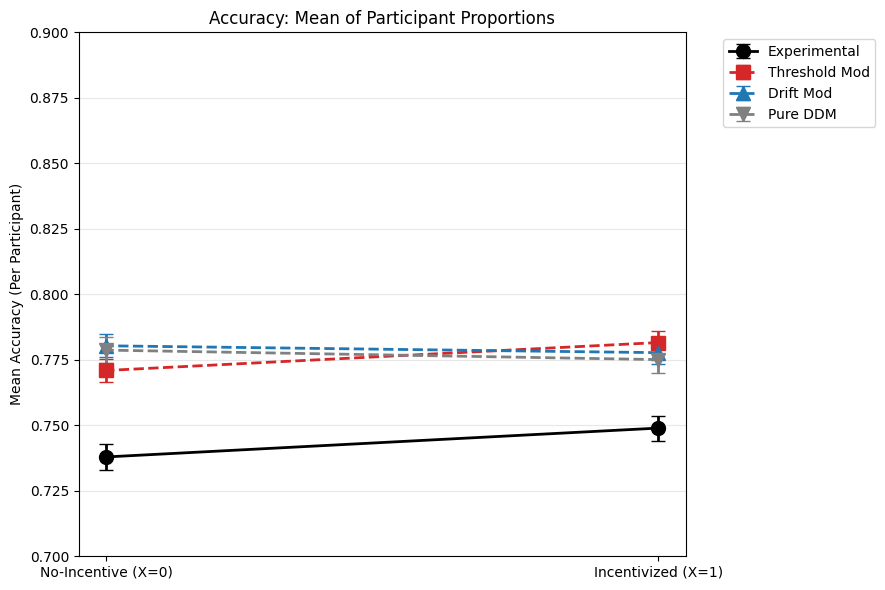

In [100]:
def plot_accuracy_per_participant(df_exp, df_th, df_v, df_pure, pid_col="participant_id"):
    def get_acc_stats(df):
        # 1. Transform response to a boolean (True for 1, False for -1) 
        # then group by participant and incentive (X) to get accuracy per person
        # This ensures a person with 75% correct is 0.75, not 0.5
        stats = df.assign(is_correct = lambda x: x['response'] == 1) \
                  .groupby([pid_col, 'X'])['is_correct'].mean().unstack()
        
        # 2. Calculate the group-level mean of those individual accuracies
        # stats[1] is Incentivized, stats[0] is No-Incentive
        means = [stats[1].mean(), stats[0].mean()]
        
        # 3. Calculate SEM (Standard Error of the Mean) across participants
        sems = [
            stats[1].std() / np.sqrt(stats[1].count()), 
            stats[0].std() / np.sqrt(stats[0].count())
        ]
        return means, sems

    # Get stats for all sources
    res_exp = get_acc_stats(df_exp)
    res_th  = get_acc_stats(df_th)
    res_v   = get_acc_stats(df_v)
    res_pure = get_acc_stats(df_pure)

    # Plotting
    plt.figure(figsize=(9, 6))
    conditions = [1, 0]
    labels = ['Incentivized (X=1)', 'No-Incentive (X=0)']
    
    # Define styles to stay consistent with your RT plots
    configs = [
        (res_exp, 'black', 'o-', 'Experimental'),
        (res_th, '#d62728', 's--', 'Threshold Mod'),
        (res_v, '#1f77b4', '^--', 'Drift Mod'),
        (res_pure, 'gray', 'v--', 'Pure DDM')
    ]

    for (m, s), color, fmt, lab in configs:
        plt.errorbar(conditions, m, yerr=s, fmt=fmt, color=color, 
                     label=lab, capsize=5, markersize=10, linewidth=2)

    plt.xticks(conditions, labels)
    plt.ylabel('Mean Accuracy (Per Participant)')
    plt.title('Accuracy: Mean of Participant Proportions')
    plt.ylim(0.7, 0.9) # Accuracy shouldn't drop below chance (0.5)
    plt.grid(axis='y', alpha=0.3)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

plot_accuracy_per_participant(df_exp, th_df, v_df, pure_df)

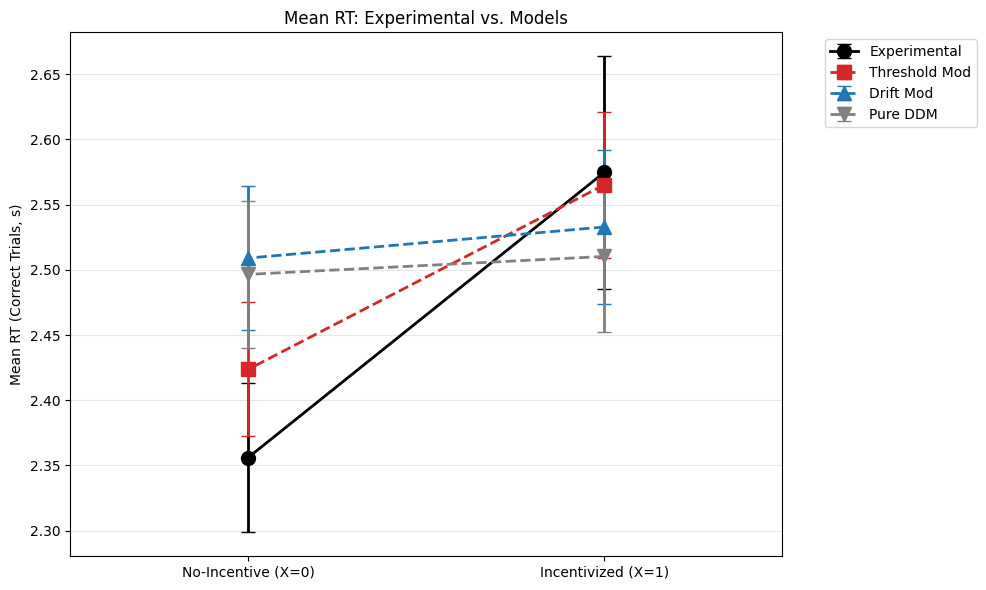

In [101]:
import matplotlib.pyplot as plt
import numpy as np

def plot_mean_rt_per_participant(df_exp, df_th, df_v, df_pure, pid_col="participant_id"):
    def get_rt_stats(df):
        # 1. Filter for CORRECT trials only (response == 1)
        # 2. Calculate mean RT per participant per condition (X)
        stats = df[df['response'] == 1].groupby([pid_col, 'X'])['rt'].mean().unstack()
        
        # 3. Group-level mean and SEM
        means = [stats[1].mean(), stats[0].mean()]
        sems = [
            stats[1].std() / np.sqrt(stats[1].count()), 
            stats[0].std() / np.sqrt(stats[0].count())
        ]
        return means, sems

    # Get stats for all sources
    res_exp = get_rt_stats(df_exp)
    res_th  = get_rt_stats(df_th)
    res_v   = get_rt_stats(df_v)
    res_pure = get_rt_stats(df_pure)

    plt.figure(figsize=(10, 6)) # Wider figure
    conditions = [1, 0]
    labels = ['Incentivized (X=1)', 'No-Incentive (X=0)']
    
    configs = [
        (res_exp, 'black', 'o-', 'Experimental'),
        (res_th, '#d62728', 's--', 'Threshold Mod'),
        (res_v, '#1f77b4', '^--', 'Drift Mod'),
        (res_pure, 'gray', 'v--', 'Pure DDM')
    ]

    for (m, s), color, fmt, lab in configs:
        plt.errorbar(conditions, m, yerr=s, fmt=fmt, color=color, 
                     label=lab, capsize=5, markersize=10, linewidth=2)

    # Formatting
    plt.xticks(conditions, labels)
    plt.ylabel('Mean RT (Correct Trials, s)')
    plt.title('Mean RT: Experimental vs. Models')
    
    # Opening up the X-axis as requested:
    plt.xlim(-0.5, 1.5) 
    
    plt.grid(axis='y', alpha=0.3)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

# Run it
plot_mean_rt_per_participant(df_exp, th_df, v_df, pure_df)

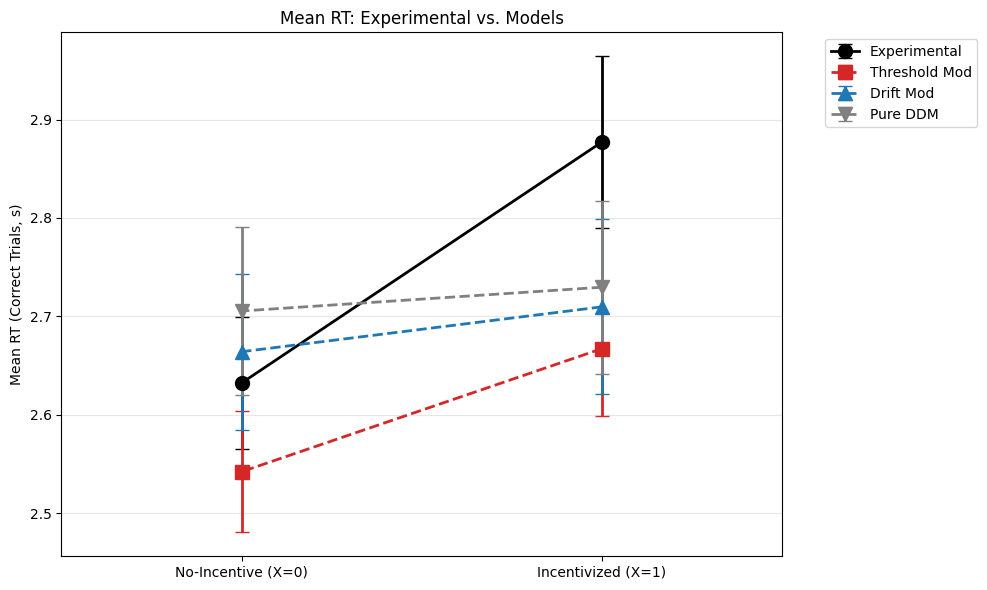

In [102]:
import matplotlib.pyplot as plt
import numpy as np

def plot_mean_rt_per_participant(df_exp, df_th, df_v, df_pure, pid_col="participant_id"):
    def get_rt_stats(df):
        # 1. Filter for CORRECT trials only (response == 1)
        # 2. Calculate mean RT per participant per condition (X)
        stats = df[df['response'] == -1].groupby([pid_col, 'X'])['rt'].mean().unstack()
        
        # 3. Group-level mean and SEM
        means = [stats[1].mean(), stats[0].mean()]
        sems = [
            stats[1].std() / np.sqrt(stats[1].count()), 
            stats[0].std() / np.sqrt(stats[0].count())
        ]
        return means, sems

    # Get stats for all sources
    res_exp = get_rt_stats(df_exp)
    res_th  = get_rt_stats(df_th)
    res_v   = get_rt_stats(df_v)
    res_pure = get_rt_stats(df_pure)

    plt.figure(figsize=(10, 6)) # Wider figure
    conditions = [1, 0]
    labels = ['Incentivized (X=1)', 'No-Incentive (X=0)']
    
    configs = [
        (res_exp, 'black', 'o-', 'Experimental'),
        (res_th, '#d62728', 's--', 'Threshold Mod'),
        (res_v, '#1f77b4', '^--', 'Drift Mod'),
        (res_pure, 'gray', 'v--', 'Pure DDM')
    ]

    for (m, s), color, fmt, lab in configs:
        plt.errorbar(conditions, m, yerr=s, fmt=fmt, color=color, 
                     label=lab, capsize=5, markersize=10, linewidth=2)

    # Formatting
    plt.xticks(conditions, labels)
    plt.ylabel('Mean RT (Correct Trials, s)')
    plt.title('Mean RT: Experimental vs. Models')
    
    # Opening up the X-axis as requested:
    plt.xlim(-0.5, 1.5) 
    
    plt.grid(axis='y', alpha=0.3)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

# Run it
plot_mean_rt_per_participant(df_exp, th_df, v_df, pure_df)